## <b>Dota 2 Hero Pick Preferences Dataset</b>

### <b>Import Libraries</b>

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from adjustText import adjust_text

### <b>Data Wrangling</b>

##### <b>Load Dataset</b>

In [71]:
df = pd.read_csv('Current_Pub_Meta.csv')

df.head(10)

,Unnamed: 0,Name,Primary Attribute,Roles,Herald Picks,Herald Wins,Herald Win Rate,Guardian Picks,Guardian Wins,Guardian Win Rate,...,Legend Win Rate,Ancient Picks,Ancient Wins,Ancient Win Rate,Divine Picks,Divine Wins,Divine Win Rate,Immortal Picks,Immortal Wins,Immortal Win Rate
0,0,Abaddon,all,"Support, Carry, Durable",1111,575,51.76,6408,3309,51.64,...,51.73,5571,2893,51.93,2632,1345,51.10,991,497,50.15
1,1,Alchemist,str,"Carry, Support, Durable, Disabler, Initiator, ...",1119,486,43.43,6370,2883,45.26,...,47.96,4120,1984,48.16,2021,1023,50.62,860,424,49.30
2,2,Ancient Apparition,int,"Support, Disabler, Nuker",2146,1073,50.00,13697,7069,51.61,...,52.63,10688,5528,51.72,5035,2573,51.10,2134,1076,50.42
3,3,Anti-Mage,agi,"Carry, Escape, Nuker",3765,1818,48.29,22050,10774,48.86,...,48.92,12303,5958,48.43,4866,2349,48.27,1502,751,50.00
4,4,Arc Warden,agi,"Carry, Escape, Nuker",1448,704,48.62,8047,4162,51.72,...,54.55,4323,2309,53.41,2104,1148,54.56,789,435,55.13
5,5,Axe,str,"Initiator, Durable, Disabler, Carry",5343,2880,53.90,32652,17719,54.27,...,50.99,22637,11353,50.15,10114,5000,49.44,3795,1837,48.41
6,6,Bane,all,"Support, Disabler, Nuker, Durable",745,334,44.83,4983,2422,48.61,...,49.66,5596,2861,51.13,3028,1555,51.35,1958,1055,53.88
7,7,Batrider,all,"Initiator, Disabler, Escape",349,136,38.97,1983,812,40.95,...,40.18,1678,731,43.56,802,362,45.14,497,227,45.67
8,8,Beastmaster,all,"Initiator, Disabler, Durable, Nuker",402,174,43.28,2447,1060,43.32,...,45.18,2816,1274,45.24,1593,752,47.21,1176,539,45.83
9,9,Bloodseeker,agi,"Carry, Disabler, Nuker, Initiator",2765,1382,49.98,12589,6270,49.81,...,49.33,6210,3006,48.41,2941,1475,50.15,1465,718,49.01


##### <b>Check Dataset Info</b>

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         124 non-null    int64  
 1   Name               124 non-null    object 
 2   Primary Attribute  124 non-null    object 
 3   Roles              124 non-null    object 
 4   Herald Picks       124 non-null    int64  
 5   Herald Wins        124 non-null    int64  
 6   Herald Win Rate    124 non-null    float64
 7   Guardian Picks     124 non-null    int64  
 8   Guardian Wins      124 non-null    int64  
 9   Guardian Win Rate  124 non-null    float64
 10  Crusader Picks     124 non-null    int64  
 11  Crusader Wins      124 non-null    int64  
 12  Crusader Win Rate  124 non-null    float64
 13  Archon Picks       124 non-null    int64  
 14  Archon Wins        124 non-null    int64  
 15  Archon Win Rate    124 non-null    float64
 16  Legend Picks       124 non

##### <b>Check Statistics Parameters</b>

In [73]:
df.describe()

,Unnamed: 0,Herald Picks,Herald Wins,Herald Win Rate,Guardian Picks,Guardian Wins,Guardian Win Rate,Crusader Picks,Crusader Wins,Crusader Win Rate,...,Legend Win Rate,Ancient Picks,Ancient Wins,Ancient Win Rate,Divine Picks,Divine Wins,Divine Win Rate,Immortal Picks,Immortal Wins,Immortal Win Rate
count,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,...,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000
mean,61.500000,2620.887097,1310.443548,48.723226,15077.096774,7538.548387,48.916855,32587.274194,16293.637097,48.990081,...,49.418871,12168.548387,6084.266129,49.586290,5835.709677,2917.854839,49.740726,2596.209677,1298.104839,49.617258
std,35.939764,1818.965847,955.388401,3.892430,10618.121662,5547.816528,3.400548,22980.786375,11934.524463,3.299540,...,2.961957,8074.669222,4115.419992,2.848079,3853.570254,1957.907344,2.631741,1794.360643,919.315721,3.058533
min,0.000000,284.000000,125.000000,37.940000,1450.000000,678.000000,40.950000,2969.000000,1345.000000,39.350000,...,40.180000,1203.000000,602.000000,41.110000,795.000000,362.000000,42.210000,338.000000,159.000000,39.450000
25%,30.750000,1180.750000,572.500000,45.580000,6606.000000,3199.500000,46.500000,14869.750000,7025.000000,47.135000,...,47.445000,5793.250000,2919.250000,47.902500,2955.250000,1467.500000,48.022500,1295.000000,629.750000,47.472500
50%,61.500000,2194.000000,1094.500000,48.635000,12443.000000,6255.500000,48.890000,26662.500000,12980.000000,49.065000,...,49.390000,10675.000000,5238.500000,49.825000,5070.000000,2488.500000,49.775000,2113.500000,1065.500000,49.535000
75%,92.250000,3704.250000,1883.250000,51.192500,20331.250000,10199.750000,51.420000,45603.750000,23384.000000,51.520000,...,51.677500,16664.500000,8670.750000,51.850000,7777.500000,3917.500000,51.527500,3386.500000,1681.750000,51.840000
max,123.000000,8553.000000,4426.000000,58.140000,50891.000000,25616.000000,56.300000,114784.000000,56289.000000,55.170000,...,54.950000,41730.000000,20239.000000,55.980000,19823.000000,9530.000000,55.670000,8276.000000,4303.000000,58.180000


##### <b>Check Missing Values</b>

In [74]:
df.isna().sum()

Unnamed: 0           0
Name                 0
Primary Attribute    0
Roles                0
Herald Picks         0
Herald Wins          0
Herald Win Rate      0
Guardian Picks       0
Guardian Wins        0
Guardian Win Rate    0
Crusader Picks       0
Crusader Wins        0
Crusader Win Rate    0
Archon Picks         0
Archon Wins          0
Archon Win Rate      0
Legend Picks         0
Legend Wins          0
Legend Win Rate      0
Ancient Picks        0
Ancient Wins         0
Ancient Win Rate     0
Divine Picks         0
Divine Wins          0
Divine Win Rate      0
Immortal Picks       0
Immortal Wins        0
Immortal Win Rate    0
dtype: int64

##### <b>Check Duplicates</b>

In [75]:
df_duplicated = df.duplicated().value_counts()

df_duplicated

False    124
Name: count, dtype: int64

### <b>Data Cleaning</b>

##### <b>Drop Leftmost Column</b>

In [76]:
# Create a copy of df
df_clean = df.copy()

# Drop the leftmost column
df_clean = df_clean.drop(df_clean.columns[0], axis=1)

df_clean.head()

,Name,Primary Attribute,Roles,Herald Picks,Herald Wins,Herald Win Rate,Guardian Picks,Guardian Wins,Guardian Win Rate,Crusader Picks,...,Legend Win Rate,Ancient Picks,Ancient Wins,Ancient Win Rate,Divine Picks,Divine Wins,Divine Win Rate,Immortal Picks,Immortal Wins,Immortal Win Rate
0,Abaddon,all,"Support, Carry, Durable",1111,575,51.76,6408,3309,51.64,13811,...,51.73,5571,2893,51.93,2632,1345,51.10,991,497,50.15
1,Alchemist,str,"Carry, Support, Durable, Disabler, Initiator, ...",1119,486,43.43,6370,2883,45.26,12238,...,47.96,4120,1984,48.16,2021,1023,50.62,860,424,49.30
2,Ancient Apparition,int,"Support, Disabler, Nuker",2146,1073,50.00,13697,7069,51.61,30673,...,52.63,10688,5528,51.72,5035,2573,51.10,2134,1076,50.42
3,Anti-Mage,agi,"Carry, Escape, Nuker",3765,1818,48.29,22050,10774,48.86,47371,...,48.92,12303,5958,48.43,4866,2349,48.27,1502,751,50.00
4,Arc Warden,agi,"Carry, Escape, Nuker",1448,704,48.62,8047,4162,51.72,14946,...,54.55,4323,2309,53.41,2104,1148,54.56,789,435,55.13


##### <b>Rename Columns</b>

In [77]:
# Lowers all column names and replace spaces with underscore
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')

# Rename columns
df_clean = df_clean.rename(columns={
    'name': 'hero_name',
    'roles': 'hero_roles'
})

df_clean.head()

,hero_name,primary_attribute,hero_roles,herald_picks,herald_wins,herald_win_rate,guardian_picks,guardian_wins,guardian_win_rate,crusader_picks,...,legend_win_rate,ancient_picks,ancient_wins,ancient_win_rate,divine_picks,divine_wins,divine_win_rate,immortal_picks,immortal_wins,immortal_win_rate
0,Abaddon,all,"Support, Carry, Durable",1111,575,51.76,6408,3309,51.64,13811,...,51.73,5571,2893,51.93,2632,1345,51.10,991,497,50.15
1,Alchemist,str,"Carry, Support, Durable, Disabler, Initiator, ...",1119,486,43.43,6370,2883,45.26,12238,...,47.96,4120,1984,48.16,2021,1023,50.62,860,424,49.30
2,Ancient Apparition,int,"Support, Disabler, Nuker",2146,1073,50.00,13697,7069,51.61,30673,...,52.63,10688,5528,51.72,5035,2573,51.10,2134,1076,50.42
3,Anti-Mage,agi,"Carry, Escape, Nuker",3765,1818,48.29,22050,10774,48.86,47371,...,48.92,12303,5958,48.43,4866,2349,48.27,1502,751,50.00
4,Arc Warden,agi,"Carry, Escape, Nuker",1448,704,48.62,8047,4162,51.72,14946,...,54.55,4323,2309,53.41,2104,1148,54.56,789,435,55.13


##### <b>Replace values in 'primary_attribute' column</b> 

In [78]:
df_clean['primary_attribute'] = df_clean['primary_attribute'].replace({
                                                    'str': 'Strength',
                                                    'int': 'Intelligence',
                                                    'agi': 'Agility',
                                                    'all': 'Universal'

})

df_clean.head()

,hero_name,primary_attribute,hero_roles,herald_picks,herald_wins,herald_win_rate,guardian_picks,guardian_wins,guardian_win_rate,crusader_picks,...,legend_win_rate,ancient_picks,ancient_wins,ancient_win_rate,divine_picks,divine_wins,divine_win_rate,immortal_picks,immortal_wins,immortal_win_rate
0,Abaddon,Universal,"Support, Carry, Durable",1111,575,51.76,6408,3309,51.64,13811,...,51.73,5571,2893,51.93,2632,1345,51.10,991,497,50.15
1,Alchemist,Strength,"Carry, Support, Durable, Disabler, Initiator, ...",1119,486,43.43,6370,2883,45.26,12238,...,47.96,4120,1984,48.16,2021,1023,50.62,860,424,49.30
2,Ancient Apparition,Intelligence,"Support, Disabler, Nuker",2146,1073,50.00,13697,7069,51.61,30673,...,52.63,10688,5528,51.72,5035,2573,51.10,2134,1076,50.42
3,Anti-Mage,Agility,"Carry, Escape, Nuker",3765,1818,48.29,22050,10774,48.86,47371,...,48.92,12303,5958,48.43,4866,2349,48.27,1502,751,50.00
4,Arc Warden,Agility,"Carry, Escape, Nuker",1448,704,48.62,8047,4162,51.72,14946,...,54.55,4323,2309,53.41,2104,1148,54.56,789,435,55.13


##### <b>Create new columns to get total picks and win rate across all brackets</b>

In [79]:
# Select columns that contains pick and wins from all brackets
pick_cols = [col for col in df_clean.columns if 'picks' in col]
win_cols = [col for col in df_clean.columns if 'wins' in col]

# Create new columns: 'total_picks' and 'total_wins'
df_clean['total_picks'] = df_clean[pick_cols].sum(axis=1)
df_clean['total_wins'] = df_clean[win_cols].sum(axis=1)

# Create 'overall_win_rate' column
df_clean['overall_win_rate'] = (df_clean['total_wins'] / df_clean['total_picks']) * 100
df_clean['overall_win_rate'] = df_clean['overall_win_rate'].round(2)

df_clean.head()

,hero_name,primary_attribute,hero_roles,herald_picks,herald_wins,herald_win_rate,guardian_picks,guardian_wins,guardian_win_rate,crusader_picks,...,ancient_win_rate,divine_picks,divine_wins,divine_win_rate,immortal_picks,immortal_wins,immortal_win_rate,total_picks,total_wins,overall_win_rate
0,Abaddon,Universal,"Support, Carry, Durable",1111,575,51.76,6408,3309,51.64,13811,...,51.93,2632,1345,51.10,991,497,50.15,58381,30076,51.52
1,Alchemist,Strength,"Carry, Support, Durable, Disabler, Initiator, ...",1119,486,43.43,6370,2883,45.26,12238,...,48.16,2021,1023,50.62,860,424,49.30,48211,22602,46.88
2,Ancient Apparition,Intelligence,"Support, Disabler, Nuker",2146,1073,50.00,13697,7069,51.61,30673,...,51.72,5035,2573,51.10,2134,1076,50.42,122632,63822,52.04
3,Anti-Mage,Agility,"Carry, Escape, Nuker",3765,1818,48.29,22050,10774,48.86,47371,...,48.43,4866,2349,48.27,1502,751,50.00,169571,83019,48.96
4,Arc Warden,Agility,"Carry, Escape, Nuker",1448,704,48.62,8047,4162,51.72,14946,...,53.41,2104,1148,54.56,789,435,55.13,55840,29782,53.33


##### <b>Explode 'hero_roles' column</b>

In [80]:
# Create copy of dataframe
df_roles = df_clean.copy()

# Change datatype from string to list
df_roles['hero_roles'] = df_roles['hero_roles'].str.split(', ')

# Explode the list
df_roles = df_roles.explode('hero_roles')

df_roles[['hero_name', 'hero_roles']].head(10)

,hero_name,hero_roles
0,Abaddon,Support
0,Abaddon,Carry
0,Abaddon,Durable
1,Alchemist,Carry
1,Alchemist,Support
1,Alchemist,Durable
1,Alchemist,Disabler
1,Alchemist,Initiator
1,Alchemist,Nuker
2,Ancient Apparition,Support


##### <b>Create new column: 'hero_complexity'</b>

In [81]:
# List of heroes that have a complexity level of 3
complexity_3 = [
	'Earth Spirit', 'Lone Druid', 'Meepo', 
	'Morphling', 'Chen', 'Invoker', 'Oracle', 
	'Rubick', 'Arc Warden', 'Brewmaster', 'Io', 'Visage',
]

# List of heroes that have a complexity level of 2
complexity_2 = [
	'Clockwerk', 'Doom', 'Earthshaker', 'Elder Titan',
	'Kunkka', 'Lifestealer', 'Lycan', 'Phoenix',
	'Pudge', 'Timbersaw', 'Tiny', 'Treant Protector',
	'Underlord', 'Broodmother', 'Clinkz', 'Ember Spirit',
	'Faceless Void', 'Hoodwink', 'Mirana', 'Monkey King',
	'Naga Siren', 'Phantom Lancer', 'Shadow Fiend', 'Slark',
	'Spectre', 'Templar Assassin', 'Terrorblade', 'Troll Warlord',
	'Weaver', 'Ancient Apparition', 'Dark Willow', 'Disruptor',
	'Enchantress', 'Grimstroke', 'Keeper of the Light', 'Outworld Destroyer',
	'Puck', 'Pugna', 'Queen of Pain', 'Shadow Demon', 'Silencer',
	'Storm Spirit', 'Tinker', 'Winter Wyvern', 'Bane', 'Batrider',
	'Beastmaster', 'Enigma', 'Magnus', 'Marci', 'Nature\'s Prophet',
	'Nyx Assassin', 'Pangolier', 'Sand King', 'Techies',
	'Void Spirit', 'Windranger',
]

# Make new column: 'complexity'
df_clean['hero_complexity'] = np.where(df_clean['hero_name'].isin(complexity_3), 3,
                                  np.where(df_clean['hero_name'].isin(complexity_2), 2,
                                  1
))

df_clean[['hero_name', 'hero_complexity']].sample(10)

,hero_name,hero_complexity
31,Elder Titan,2
119,Windranger,2
45,Kunkka,2
5,Axe,1
70,Omniknight,1
115,Visage,3
11,Brewmaster,3
88,Shadow Shaman,1
74,Phantom Assassin,1
100,Templar Assassin,2


In [82]:
df_clean['hero_complexity'].isna().value_counts()

hero_complexity
False    124
Name: count, dtype: int64

##### <b>Melt Columns</b>

In [83]:
# Melt picks columns
df_melted_picks = pd.melt(
    df_clean, 
    id_vars=['hero_name', 'primary_attribute', 'hero_complexity'], 
    value_vars=pick_cols, 
    var_name='bracket', 
    value_name='picks'  
)

df_melted_picks['bracket'] = df_melted_picks['bracket'].str.replace('_picks', '').str.capitalize()

# Get total picks per bracket
picks_per_bracket = df_melted_picks.groupby('bracket')['picks'].transform('sum')

# Make new column: 'pick_percentage'
df_melted_picks['pick_percentage'] = (df_melted_picks['picks'] / picks_per_bracket) * 100

df_melted_picks

,hero_name,primary_attribute,hero_complexity,bracket,picks,pick_percentage
0,Abaddon,Universal,1,Herald,1111,0.341857
1,Alchemist,Strength,1,Herald,1119,0.344318
2,Ancient Apparition,Intelligence,2,Herald,2146,0.660328
3,Anti-Mage,Agility,1,Herald,3765,1.158497
4,Arc Warden,Agility,3,Herald,1448,0.445552
...,...,...,...,...,...,...
987,Windranger,Universal,2,Immortal,2374,0.737427
988,Winter Wyvern,Universal,2,Immortal,944,0.293231
989,Witch Doctor,Intelligence,1,Immortal,4196,1.303389
990,Wraith King,Strength,1,Immortal,2707,0.840866


In [84]:
# Get columns containing win_rate
win_rate_cols = [col for col in df_clean.columns if 'win_rate' in col]

# Pop overall_win_rate column
win_rate_cols.pop()

# Melt win rate columns
df_melted_win_rate = pd.melt(
    df_clean, 
    id_vars=['hero_name', 'primary_attribute', 'hero_complexity'], 
    value_vars=win_rate_cols, 
    var_name='bracket', 
    value_name='win_rate'  
)

df_melted_win_rate['bracket'] = df_melted_win_rate['bracket'].str.replace('_win_rate', '').str.capitalize()

df_melted_win_rate

,hero_name,primary_attribute,hero_complexity,bracket,win_rate
0,Abaddon,Universal,1,Herald,51.76
1,Alchemist,Strength,1,Herald,43.43
2,Ancient Apparition,Intelligence,2,Herald,50.00
3,Anti-Mage,Agility,1,Herald,48.29
4,Arc Warden,Agility,3,Herald,48.62
...,...,...,...,...,...
987,Windranger,Universal,2,Immortal,48.10
988,Winter Wyvern,Universal,2,Immortal,49.15
989,Witch Doctor,Intelligence,1,Immortal,49.48
990,Wraith King,Strength,1,Immortal,50.83


In [85]:
# Merge melted dataframes
df_melted_all = pd.merge(
    df_melted_picks,
    df_melted_win_rate,
    on=['hero_name', 'primary_attribute', 'hero_complexity', 'bracket'],
    how='inner'
)

df_melted_all

,hero_name,primary_attribute,hero_complexity,bracket,picks,pick_percentage,win_rate
0,Abaddon,Universal,1,Herald,1111,0.341857,51.76
1,Alchemist,Strength,1,Herald,1119,0.344318,43.43
2,Ancient Apparition,Intelligence,2,Herald,2146,0.660328,50.00
3,Anti-Mage,Agility,1,Herald,3765,1.158497,48.29
4,Arc Warden,Agility,3,Herald,1448,0.445552,48.62
...,...,...,...,...,...,...,...
987,Windranger,Universal,2,Immortal,2374,0.737427,48.10
988,Winter Wyvern,Universal,2,Immortal,944,0.293231,49.15
989,Witch Doctor,Intelligence,1,Immortal,4196,1.303389,49.48
990,Wraith King,Strength,1,Immortal,2707,0.840866,50.83


##### <b>Set Bracket Order</b>

In [86]:
# Tell Python the bracket order
rank_order = ['Herald', 'Guardian', 'Crusader', 'Archon', 'Legend', 'Ancient', 'Divine', 'Immortal']

df_to_order = [df_melted_all]

for x in df_to_order:
    x['bracket'] = pd.Categorical(
        x['bracket'],
        categories=rank_order,
        ordered=True
    )

##### <b>Data Sanity Check</b>

In [87]:
# Check if Wins > Picks
invalid_wins = df_clean[df_clean['total_wins'] > df_clean['total_picks']]

if invalid_wins.empty:
    print("Sanity Check OK: No Total Wins that Exceeds Total Picks.")
else:
    print("Warning: Odd data detected")

# Check if Win Rate is in normal interval (0-100)
invalid_wr = df_clean[(df_clean['overall_win_rate'] < 0) | (df_clean['overall_win_rate'] > 100)]
if invalid_wr.empty:
     print("Sanity Check OK: Win Rate values are in normal interval.")
else:
    print("Warning: Odd data detected")

Sanity Check OK: No Total Wins that Exceeds Total Picks.
Sanity Check OK: Win Rate values are in normal interval.


##### <b>Cleaned Data Final</b>

In [88]:
df_clean.head()

,hero_name,primary_attribute,hero_roles,herald_picks,herald_wins,herald_win_rate,guardian_picks,guardian_wins,guardian_win_rate,crusader_picks,...,divine_picks,divine_wins,divine_win_rate,immortal_picks,immortal_wins,immortal_win_rate,total_picks,total_wins,overall_win_rate,hero_complexity
0,Abaddon,Universal,"Support, Carry, Durable",1111,575,51.76,6408,3309,51.64,13811,...,2632,1345,51.10,991,497,50.15,58381,30076,51.52,1
1,Alchemist,Strength,"Carry, Support, Durable, Disabler, Initiator, ...",1119,486,43.43,6370,2883,45.26,12238,...,2021,1023,50.62,860,424,49.30,48211,22602,46.88,1
2,Ancient Apparition,Intelligence,"Support, Disabler, Nuker",2146,1073,50.00,13697,7069,51.61,30673,...,5035,2573,51.10,2134,1076,50.42,122632,63822,52.04,2
3,Anti-Mage,Agility,"Carry, Escape, Nuker",3765,1818,48.29,22050,10774,48.86,47371,...,4866,2349,48.27,1502,751,50.00,169571,83019,48.96,1
4,Arc Warden,Agility,"Carry, Escape, Nuker",1448,704,48.62,8047,4162,51.72,14946,...,2104,1148,54.56,789,435,55.13,55840,29782,53.33,3


In [89]:
df_roles.head()

,hero_name,primary_attribute,hero_roles,herald_picks,herald_wins,herald_win_rate,guardian_picks,guardian_wins,guardian_win_rate,crusader_picks,...,ancient_win_rate,divine_picks,divine_wins,divine_win_rate,immortal_picks,immortal_wins,immortal_win_rate,total_picks,total_wins,overall_win_rate
0,Abaddon,Universal,Support,1111,575,51.76,6408,3309,51.64,13811,...,51.93,2632,1345,51.10,991,497,50.15,58381,30076,51.52
0,Abaddon,Universal,Carry,1111,575,51.76,6408,3309,51.64,13811,...,51.93,2632,1345,51.10,991,497,50.15,58381,30076,51.52
0,Abaddon,Universal,Durable,1111,575,51.76,6408,3309,51.64,13811,...,51.93,2632,1345,51.10,991,497,50.15,58381,30076,51.52
1,Alchemist,Strength,Carry,1119,486,43.43,6370,2883,45.26,12238,...,48.16,2021,1023,50.62,860,424,49.30,48211,22602,46.88
1,Alchemist,Strength,Support,1119,486,43.43,6370,2883,45.26,12238,...,48.16,2021,1023,50.62,860,424,49.30,48211,22602,46.88


In [90]:
df_melted_all.head()

,hero_name,primary_attribute,hero_complexity,bracket,picks,pick_percentage,win_rate
0,Abaddon,Universal,1,Herald,1111,0.341857,51.76
1,Alchemist,Strength,1,Herald,1119,0.344318,43.43
2,Ancient Apparition,Intelligence,2,Herald,2146,0.660328,50.00
3,Anti-Mage,Agility,1,Herald,3765,1.158497,48.29
4,Arc Warden,Agility,3,Herald,1448,0.445552,48.62


### <b>EDA</b>

##### <b>Most Picked Attribute</b>

In [91]:
df_attribute_pick = df_clean.groupby('primary_attribute')['total_picks'].sum().reset_index()
df_attribute_pick = df_attribute_pick.sort_values(by='total_picks', ascending=False)

df_attribute_pick

,primary_attribute,total_picks
1,Intelligence,4799206
2,Strength,4528416
0,Agility,4391377
3,Universal,2757669


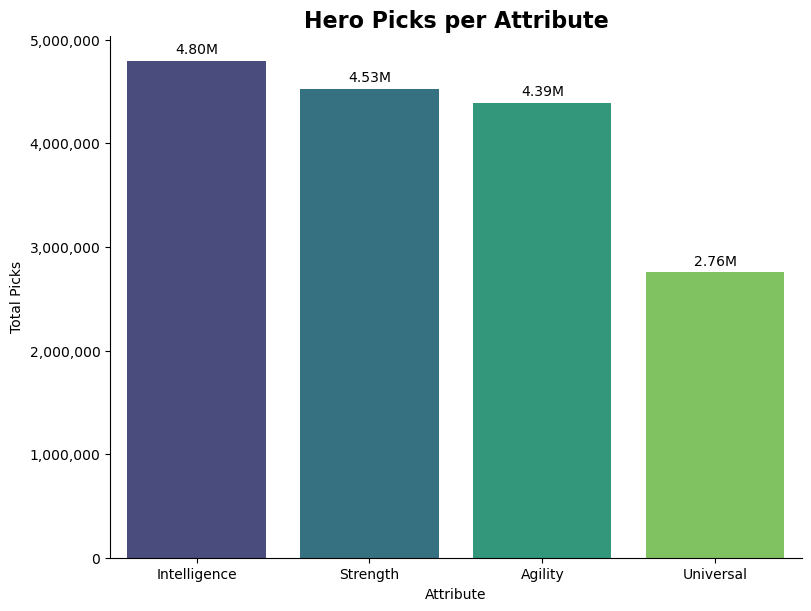

In [92]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')

sns.barplot(
    df_attribute_pick,
    x='primary_attribute',
    y='total_picks',
    palette='viridis',
    hue='primary_attribute',
    ax=ax
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Bar labels
for container in ax.containers:
    labels = [f'{val/1000000:.2f}M' for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

ax.set_title('Hero Picks per Attribute', fontweight='bold', fontsize=16)
ax.set_xlabel('Attribute')
ax.set_ylabel('Total Picks')

sns.despine()

plt.show()

##### <b>Most Picked Roles</b>

In [93]:
df_most_roles = df_roles.groupby('hero_roles')['total_picks'].sum().reset_index()
df_most_roles = df_most_roles.sort_values(by='total_picks', ascending=False)

df_most_roles

,hero_roles,total_picks
1,Disabler,12270728
5,Nuker,11894693
0,Carry,9867325
4,Initiator,7181460
3,Escape,6454620
7,Support,6193618
2,Durable,5961155
6,Pusher,3032224


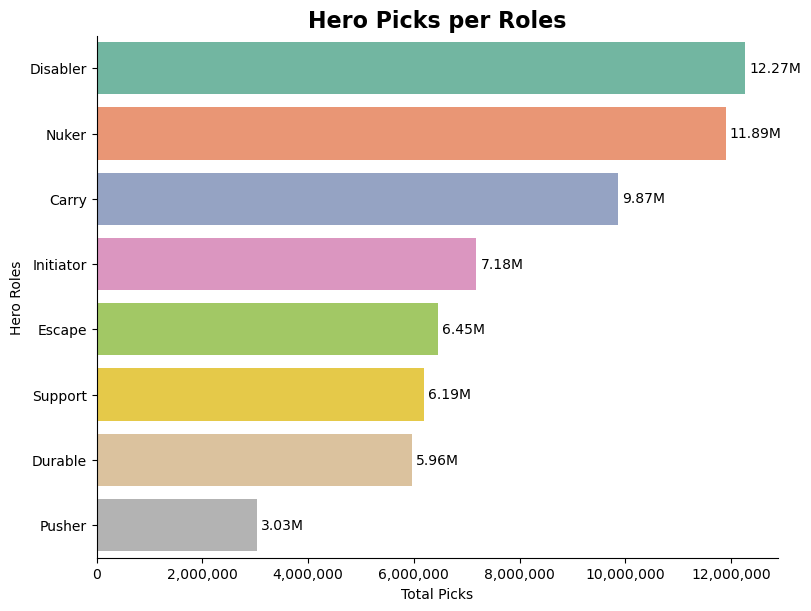

In [94]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')

sns.barplot(
    df_most_roles,
    x='total_picks',
    y='hero_roles',
    palette='Set2',
    hue='hero_roles',
    ax=ax
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Bar labels
for container in ax.containers:
    labels = [f'{val/1000000:.2f}M' for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

ax.set_title('Hero Picks per Roles', fontweight='bold', fontsize=16)
ax.set_xlabel('Total Picks')
ax.set_ylabel('Hero Roles')

sns.despine()

plt.show()

##### <b>Most Picked Heroes per Bracket</b>

In [95]:
df_most_heroes = df_melted_all.sort_values(by=['bracket', 'picks'], ascending=False)
df_most_heroes = df_most_heroes.groupby('bracket').head(5)

df_most_heroes

C:\Users\Rio\AppData\Local\Temp\ipykernel_844\1343531972.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_most_heroes = df_most_heroes.groupby('bracket').head(5)


,hero_name,primary_attribute,hero_complexity,bracket,picks,pick_percentage,win_rate
980,Vengeful Spirit,Universal,1,Immortal,8276,2.570745,51.99
908,Invoker,Universal,3,Immortal,7852,2.439040,52.83
942,Phantom Assassin,Agility,1,Immortal,7819,2.428789,49.32
933,Nature's Prophet,Intelligence,2,Immortal,7182,2.230920,52.28
947,Pudge,Strength,2,Immortal,7112,2.209176,48.24
823,Pudge,Strength,2,Divine,19823,2.739391,48.08
818,Phantom Assassin,Agility,1,Divine,17774,2.456234,51.07
809,Nature's Prophet,Intelligence,2,Divine,16585,2.291923,52.73
784,Invoker,Universal,3,Divine,15431,2.132449,53.11
865,Witch Doctor,Intelligence,1,Divine,14610,2.018993,50.94


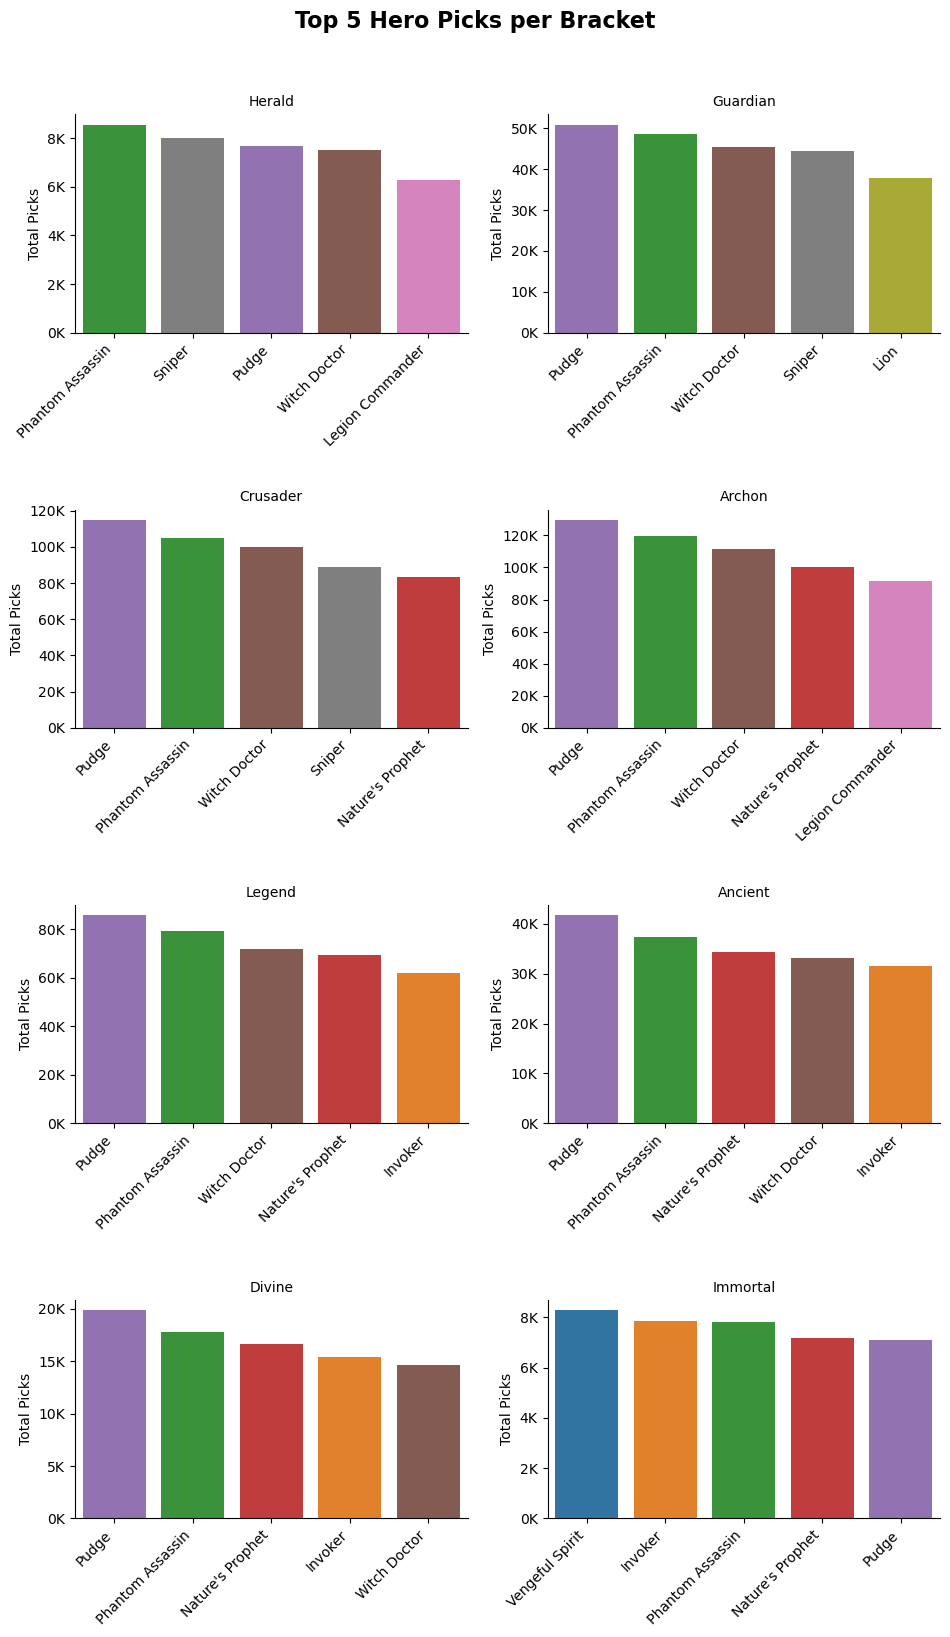

In [96]:
# Visualization

g = sns.catplot(
    data=df_most_heroes,
    x='hero_name',
    y='picks',
    col='bracket',
    col_wrap=2,
    sharex=False,
    sharey=False,
    kind='bar',
    hue='hero_name',
    palette='tab10',
    dodge=False,
    height=4,
    aspect=1.2,
)

formatter = FuncFormatter(lambda x, pos: f"{int(x/1000)}K")


for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.yaxis.set_major_formatter(formatter)
    ax.set_ylabel('Total Picks')

g.set_titles('{col_name}')
g.set_xlabels('')
g.fig.suptitle('Top 5 Hero Picks per Bracket', y=1.02, fontsize=16, fontweight='bold')

plt.tight_layout(h_pad=3)

plt.show()

##### <b>Top Hero Win Rate per Bracket</b>

In [97]:
df_hero_win_rate = df_melted_all.sort_values(by=['bracket', 'win_rate'], ascending=False)
df_hero_win_rate = df_hero_win_rate.groupby('bracket').head(5)

df_hero_win_rate

C:\Users\Rio\AppData\Local\Temp\ipykernel_844\1518297762.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hero_win_rate = df_hero_win_rate.groupby('bracket').head(5)


,hero_name,primary_attribute,hero_complexity,bracket,picks,pick_percentage,win_rate
884,Chen,Universal,3,Immortal,770,0.239182,58.18
974,Treant Protector,Strength,2,Immortal,6801,2.112571,56.68
986,Weaver,Agility,2,Immortal,1303,0.404746,55.18
872,Arc Warden,Agility,3,Immortal,789,0.245084,55.13
913,Kunkka,Strength,2,Immortal,3458,1.074147,54.89
796,Lone Druid,Universal,3,Divine,4024,0.556087,55.67
850,Treant Protector,Strength,2,Divine,9870,1.363960,55.40
789,Kunkka,Strength,2,Divine,7884,1.089510,55.04
748,Arc Warden,Agility,3,Divine,2104,0.290757,54.56
775,Elder Titan,Strength,2,Divine,1124,0.155328,54.54


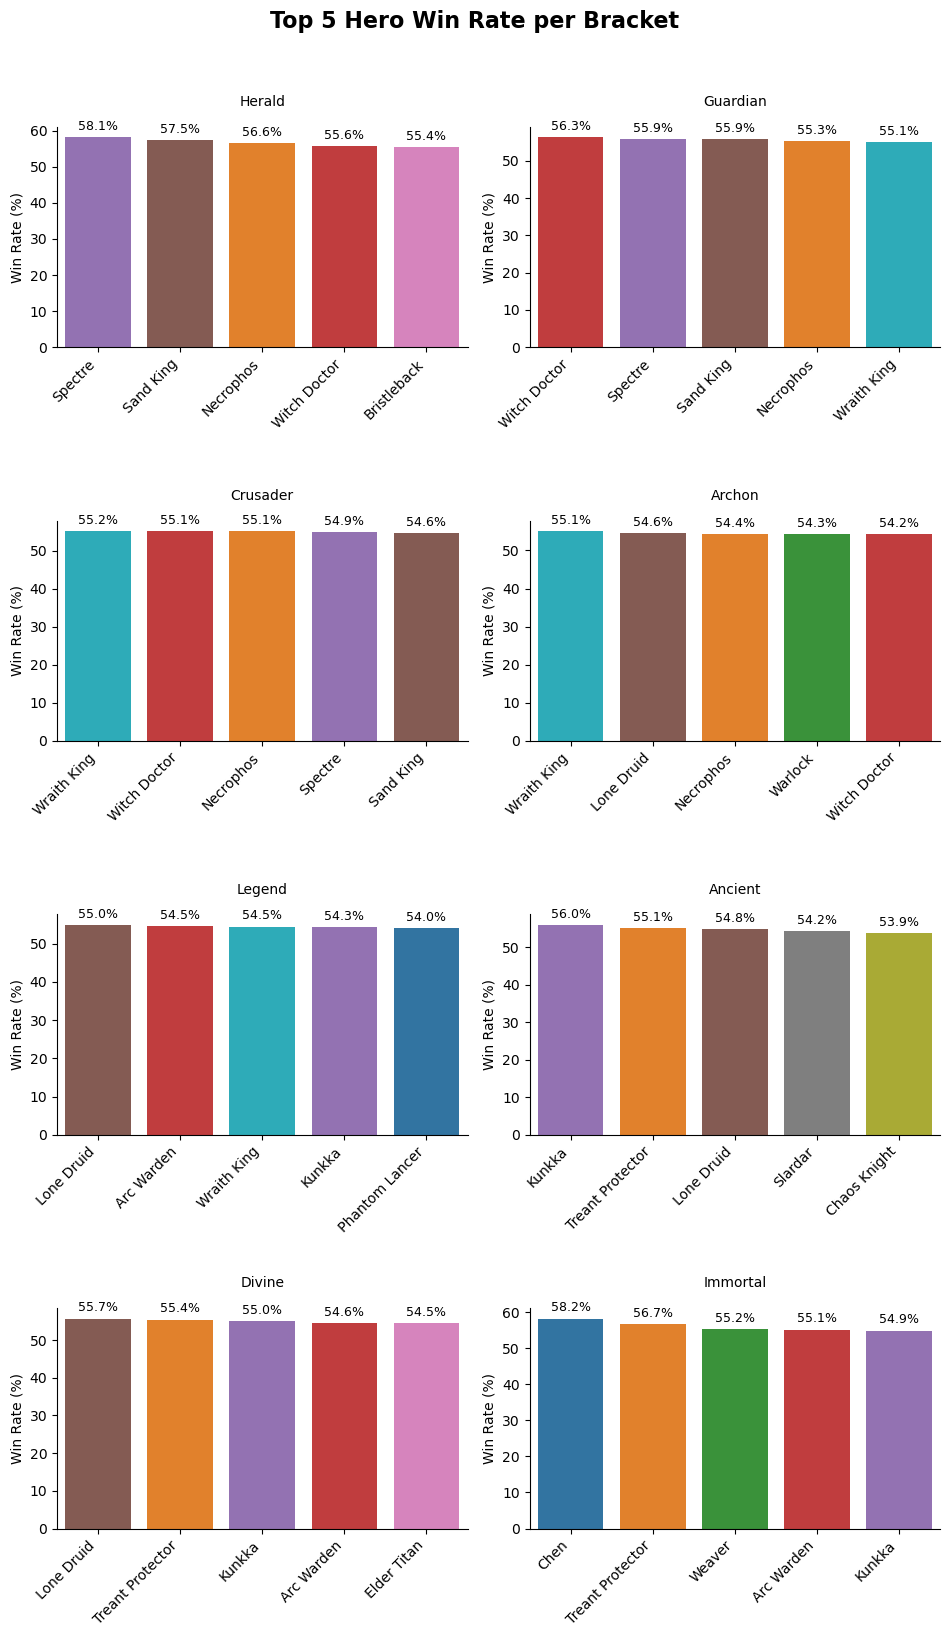

In [98]:
# Visualization

g = sns.catplot(
    data=df_hero_win_rate,
    x='hero_name',
    y='win_rate',
    col='bracket',
    col_wrap=2,
    sharex=False,
    sharey=False,
    kind='bar',
    hue='hero_name',
    palette='tab10',
    dodge=False,
    height=4,
    aspect=1.2,
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.set_ylabel('Win Rate (%)')

    for container in ax.containers:
        labels = [f'{wr:.1f}%' for wr in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

g.set_titles('{col_name}', pad=15)
g.set_xlabels('')
g.fig.suptitle('Top 5 Hero Win Rate per Bracket', y=1.02, fontsize=16, fontweight='bold')

plt.tight_layout(h_pad=3)

plt.show()

##### <b>Does hero complexity influences pick-rate?</b>

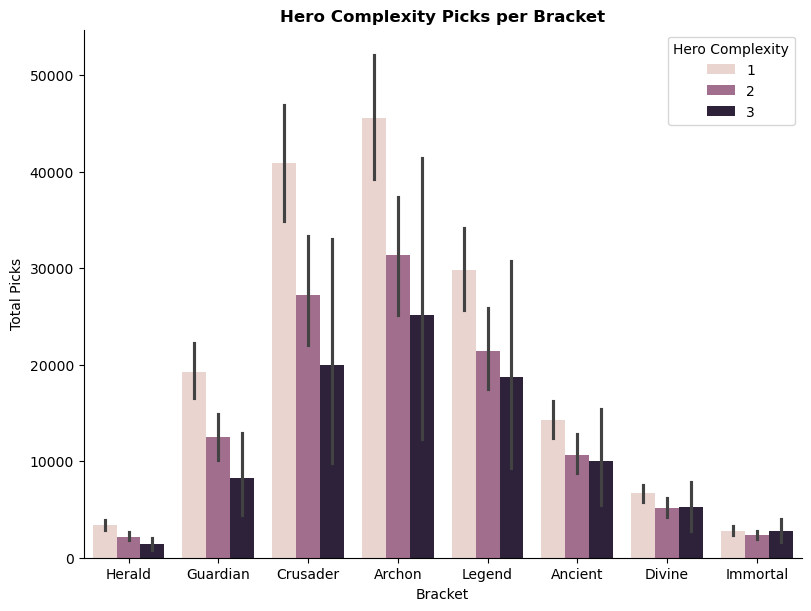

In [99]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')

sns.barplot(
    data=df_melted_all,
    x='bracket',
    y='picks',
    hue='hero_complexity',
    ax=ax
)

legend = ax.get_legend()

ax.set_title('Hero Complexity Picks per Bracket', fontweight='bold')
ax.set_xlabel('Bracket')
ax.set_ylabel('Total Picks')
legend.set_title('Hero Complexity')

sns.despine()

plt.show()

##### <b>Variance of Hero Picks per Bracket</b>

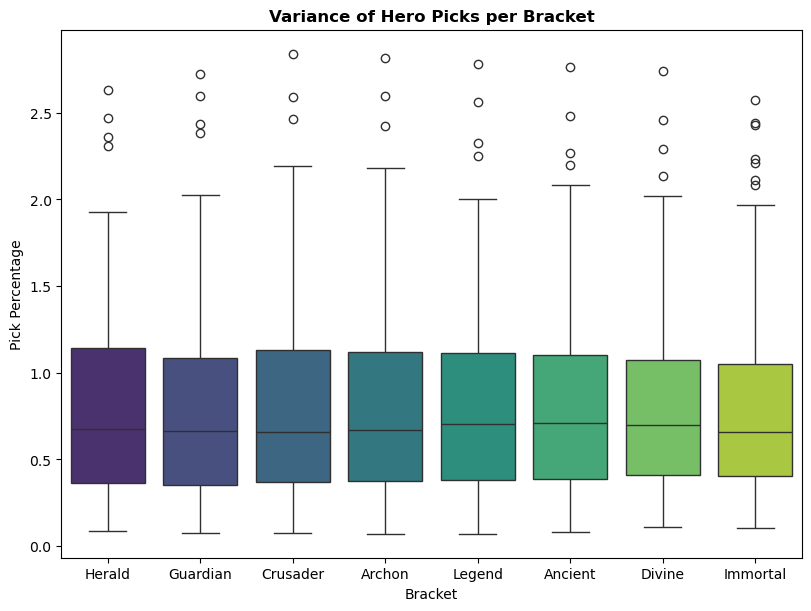

In [100]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')

sns.boxplot(
    data=df_melted_all,
    x='bracket',
    y='pick_percentage',
    showfliers=True,
    palette='viridis',
    hue='bracket',
    legend=False
)

ax.set_title('Variance of Hero Picks per Bracket', fontweight='bold')
ax.set_xlabel('Bracket')
ax.set_ylabel('Pick Percentage')

plt.show()

##### <b>Hero Picks Scatter Plot</b>

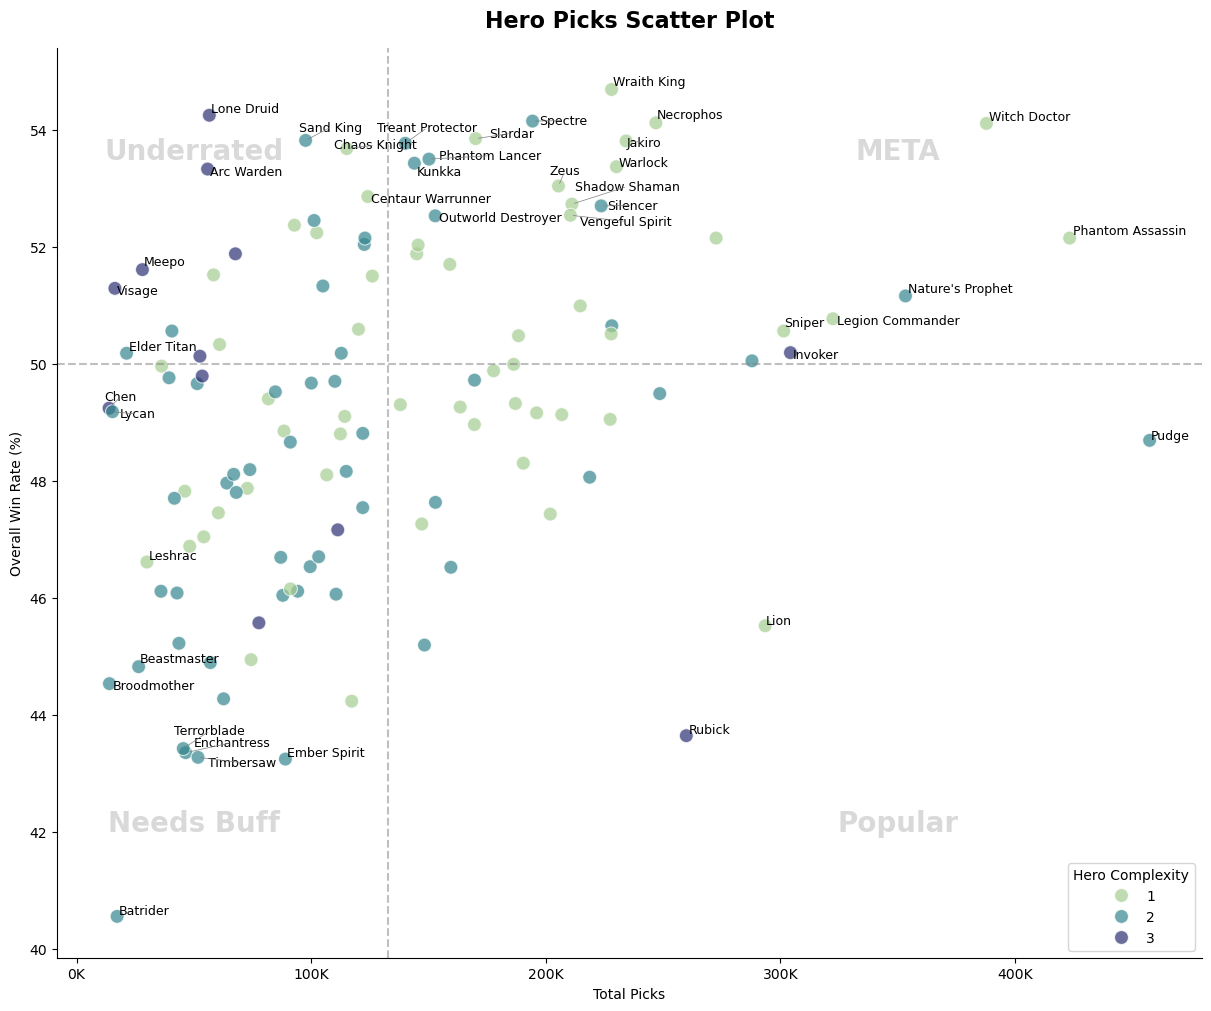

In [105]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 10), layout='constrained')

sns.scatterplot(
    data=df_clean, 
    x='total_picks', 
    y='overall_win_rate',
    hue='hero_complexity',
    palette='crest',
    s=100,
    alpha=0.7
)

# Make quadrant lines
middle_line_pick = df_clean['total_picks'].mean()
middle_line_wr = 50.0

plt.axvline(middle_line_pick, color='grey', linestyle='--', alpha=0.5)
plt.axhline(middle_line_wr, color='grey', linestyle='--', alpha=0.5)

texts = []

# Selective Labeling (Only for extreme heroes)
for i in range(df_clean.shape[0]):
    picks = df_clean['total_picks'].iloc[i]
    wr = df_clean['overall_win_rate'].iloc[i]
    hero_name = df_clean['hero_name'].iloc[i]
    
    if wr > 52.5 or wr < 44 or picks > 290_000 or picks < 30_000:
        texts.append(plt.text(x=picks, y=wr, s=hero_name, fontsize=9))

adjust_text(
    texts, 
    arrowprops=dict(arrowstyle="-", color='gray', lw=0.5), 
    expand_points=(1.5, 1.5) 
)

legend = ax.get_legend()

ax.set_title('Hero Picks Scatter Plot', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Picks')
ax.set_ylabel('Overall Win Rate (%)')
legend.set_title('Hero Complexity')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x/1000)}K"))

ax.text(x=350_000, y=53.5, s='META', fontsize=20, alpha=0.15, fontweight='bold', ha='center')
ax.text(x=350_000, y=42, s='Popular', fontsize=20, alpha=0.15, fontweight='bold', ha='center')
ax.text(x=50_000, y=53.5, s='Underrated', fontsize=20, alpha=0.15, fontweight='bold', ha='center')
ax.text(x=50_000, y=42, s='Needs Buff', fontsize=20, alpha=0.15, fontweight='bold', ha='center')

sns.despine()
plt.show()